# Tutorial 5: Fitting Individual Stars with BruteForce

This tutorial demonstrates how to fit individual stars using brutus's BruteForce class, which performs fast Bayesian inference over pre-computed model grids.

## Topics Covered

1. **Data preparation** (flux units, parallaxes, coordinates)
2. **BruteForce class** setup and configuration
3. **Running fits** with various options
4. **Result visualization** and interpretation

## Prerequisites

This tutorial requires the following brutus data files:
- `grid_mist_v9.h5` - MIST model grid
- `offsets_mist_v9.txt` - Photometric offsets
- `Orion_l204.7_b-19.2.h5` - Example Orion field data (included in `tutorials/`)
- `bayestar2019_v1.h5` (optional) - 3D dust map

If you don't have these files, run the download cell below.

In [1]:
# Download required data files (if not already available locally)
from tutorial_utils import find_brutus_data_file
from brutus.data import fetch_grids, fetch_offsets

# Download grid and offsets if needed
fetch_grids()       # Downloads MIST model grid
fetch_offsets('mist_v9')  # Downloads photometric offsets

# Check dustmap availability (large file, ~2 GB)
try:
    dustmap_path = find_brutus_data_file('bayestar2019_v1.h5')
    print(f"Dustmap found: {dustmap_path}")
except FileNotFoundError:
    from brutus.data import fetch_dustmaps
    fetch_dustmaps()  # Downloads Bayestar dust map
    print("Dustmap downloaded.")

# Note: The Orion field data is included in the tutorials/ directory.

Dustmap found: /home/joshspeagle/.cache/astro-brutus/bayestar2019_v1.h5


In [2]:
# Imports and setup
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from tutorial_utils import (
    setup_tutorial,
    find_brutus_data_file,
    save_figure as _save_fig,
    print_section,
    load_orion_data,
)

info = setup_tutorial(5, title="Tutorial 05: Fitting Individual Stars with BruteForce")
plots_dir = info['plot_dir']


def save_figure(fig, name):
    """Save figure to this tutorial's plot directory."""
    _save_fig(fig, 5, name)


Tutorial 05: Fitting Individual Stars with BruteForce

Checking data requirements for Tutorial 5
  Found: grid_mist_v9.h5
  Found: offsets_mist_v9.txt
  Found: bayestar2019_v1.h5
  Found: Orion_l204.7_b-19.2.h5

  All required files available


## Section 1: Data Preparation for BruteForce

BruteForce requires specific data formats:
- **Photometry in flux units** (maggies = 10^(-0.4 * magnitude))
- **Parallaxes in mas** (milliarcseconds) from Gaia
- **Galactic coordinates** (l, b) for applying priors

Let's load and examine the Orion field data.

In [3]:
from brutus.utils import inv_magnitude, magnitude

# Load example Orion field data
print("Loading Orion field data...")
data = load_orion_data()

print(f"\nLoaded {len(data['phot'])} sources")
print(f"  Photometry shape: {data['phot'].shape}")
print(f"  Filters: Pan-STARRS (grizy) + 2MASS (JHKs) = 8 bands")
print(f"  Valid parallaxes: {np.sum(np.isfinite(data['parallax']))}")
print(f"  Coordinate range: l=[{data['coords'][:, 0].min():.1f}, {data['coords'][:, 0].max():.1f}], "
      f"b=[{data['coords'][:, 1].min():.1f}, {data['coords'][:, 1].max():.1f}] deg")

Loading Orion field data...

Loaded 1642 sources
  Photometry shape: (1642, 8)
  Filters: Pan-STARRS (grizy) + 2MASS (JHKs) = 8 bands
  Valid parallaxes: 1201
  Coordinate range: l=[204.5, 204.9], b=[-19.4, -19.0] deg


## Section 2: BruteForce Class Setup

BruteForce performs fast stellar parameter inference by:
1. **Evaluating likelihood** over a pre-computed grid of stellar models
2. **Marginalizing analytically** over nuisance parameters (distance, extinction)
3. **Incorporating priors** (Galactic structure, 3D dust, parallax)

Let's load the MIST model grid and initialize BruteForce.

In [4]:
from brutus.analysis import BruteForce
from brutus.core import StarGrid
from brutus.data import load_models, filters

# Load MIST model grid
print("Loading MIST model grid...")
grid_file = find_brutus_data_file('grid_mist_v9.h5')

# Define filters (Pan-STARRS + 2MASS)
filt = filters.ps[:-2] + filters.tmass  # Skip PS w and open bands
print(f"\nUsing filters: {filt}")

# Load models
models, labels, label_mask = load_models(grid_file, filters=filt)

print(f"\nLoaded {len(models):,} models")
print(f"  Model shape: {models.shape}")
print(f"  Parameter fields: {list(labels.dtype.names)}")
print(f"  Key parameters:")
print(f"    Mass range: [{labels['mini'].min():.2f}, {labels['mini'].max():.1f}] M_sun")
print(f"    [Fe/H] range: [{labels['feh'].min():.2f}, {labels['feh'].max():.2f}]")
print(f"    log(age) range: [{labels['loga'].min():.2f}, {labels['loga'].max():.2f}]")

# Create StarGrid and initialize BruteForce
grid = StarGrid(models, labels)
bf = BruteForce(grid)

print(f"\nBruteForce initialized with {len(filt)} bands")

Loading MIST model grid...

Using filters: ['PS_g', 'PS_r', 'PS_i', 'PS_z', 'PS_y', '2MASS_J', '2MASS_H', '2MASS_Ks']


Reading entire dataset (49 filters) once...


Extracting 8 requested filters from memory...



Loaded 613,530 models
  Model shape: (613530, 8, 3)
  Parameter fields: ['mini', 'feh', 'eep', 'loga', 'logl', 'logt', 'logg', 'agewt']
  Key parameters:
    Mass range: [0.50, 2.0] M_sun
    [Fe/H] range: [-3.00, 0.45]
    log(age) range: [6.46, 10.14]
Loaded StarGrid with 613,530 models, 8 filters, 8 labels
BruteForce initialized with 613,530 models
  Grid parameters (8): mini, feh, eep, loga, logl, logt, logg, agewt

BruteForce initialized with 8 bands


## Section 3: Running BruteForce Fits

Now let's fit a subset of sources from the Orion field, demonstrating various fitting options.

Key considerations:
- **Photometric offsets** calibrate models to match observed photometry
- **3D dust maps** provide extinction priors
- **Parallax constraints** from Gaia improve distance estimates
- **Galactic priors** based on position help constrain parameters

In [5]:
# Load photometric offsets (calibration corrections)
from brutus.data import load_offsets

print("Loading photometric offsets...")
try:
    offsets_file = find_brutus_data_file('offsets_mist_v9.txt')
    offsets_mist = load_offsets(offsets_file, filters=filt)
    print("\nPhotometric offsets (multiplicative flux):")
    for band, offset in zip(filt, offsets_mist):
        print(f"  {band}: {offset:.4f}")
except FileNotFoundError:
    offsets_mist = np.ones(len(filt))
    print("  Offsets file not found, using unity offsets")

# Select subset for fitting (sources with good data)
good_sources = np.sum(data['mask'], axis=1) >= 5  # At least 5 bands
has_parallax = np.isfinite(data['parallax']) & (data['parallax'] > 0)
idx_fit = np.where(good_sources & has_parallax)[0][:50]  # First 50 good sources

print(f"\nSelected {len(idx_fit)} sources for fitting")
print(f"  Criteria: >=5 bands detected AND valid parallax")
print(f"  Average bands per source: {np.mean(np.sum(data['mask'][idx_fit], axis=1)):.1f}")

# Try to load 3D dust map
try:
    dustfile = find_brutus_data_file('bayestar2019_v1.h5')
    print("\n3D dust map (Bayestar) available")
except FileNotFoundError:
    dustfile = None
    print("\n3D dust map not available (will use flat prior)")

Loading photometric offsets...

Photometric offsets (multiplicative flux):
  PS_g: 1.0000
  PS_r: 0.9500
  PS_i: 0.9600
  PS_z: 0.9400
  PS_y: 0.9500
  2MASS_J: 0.9800
  2MASS_H: 1.0400
  2MASS_Ks: 1.0300

Selected 50 sources for fitting
  Criteria: >=5 bands detected AND valid parallax
  Average bands per source: 6.8

3D dust map (Bayestar) available


PS_g (0.0%)
PS_r (-5.0%)
PS_i (-4.0%)
PS_z (-6.0%)
PS_y (-5.0%)
2MASS_J (-2.0%)
2MASS_H (4.0%)
2MASS_Ks (3.0%)


> **Note:** Users can disable the 3D dust map prior (making it flat over A(V)) by not passing the `dustfile` argument to `bf.fit()`.

In [6]:
# Run BruteForce fits
output_file = plots_dir / 'orion_fits_mist.h5'

print(f"Running BruteForce fits on {len(idx_fit)} sources...")

bf.fit(
    data=data['phot'][idx_fit],
    data_err=data['err'][idx_fit],
    data_mask=data['mask'][idx_fit],
    data_labels=idx_fit,
    save_file=str(output_file),
    data_coords=data['coords'][idx_fit],
    parallax=data['parallax'][idx_fit],
    parallax_err=data['parallax_err'][idx_fit],
    phot_offsets=offsets_mist,
    dustfile=dustfile,
    Ndraws=500,
    Nmc_prior=20,
    logl_dim_prior=True,
    save_dar_draws=True,
    running_io=False,
    verbose=True
)

print(f"\nFitting complete! Results saved to {output_file}")

Running BruteForce fits on 50 sources...


Fitting object 1/50  

Fitting object 2/50 [chi2/n: 0.1/6] (mean time: 7.573 s/obj, est. remaining: 371.088 s)    

Fitting object 3/50 [chi2/n: 1.8/7] (mean time: 3.984 s/obj, est. remaining: 191.239 s)    

Fitting object 4/50 [chi2/n: 4.4/9] (mean time: 2.823 s/obj, est. remaining: 132.678 s)    

...

Fitting object 48/50 [chi2/n: 4.0/9] (mean time: 0.554 s/obj, est. remaining: 1.662 s)    

Fitting object 49/50 [chi2/n: 44.2/9] (mean time: 0.553 s/obj, est. remaining: 1.105 s)    

Fitting object 50/50 [chi2/n: 0.5/7] (mean time: 0.555 s/obj, est. remaining: 0.555 s)    

Fitting object 50/50 [chi2/n: 6.6/8] (mean time: 0.550 s/obj, total: 27.511 s)    



Fitting complete! Results saved to /mnt/c/Users/joshs/Dropbox/GitHub/brutus/tutorials/plots/tutorial_05/orion_fits_mist.h5


Loaded fitting results:
  chi2 values: (50,)
  Model indices: (50, 500)
  ML scale/AV/RV: (50, 500)
  Distance samples: (50, 500)


  Saved: /mnt/c/Users/joshs/Dropbox/GitHub/brutus/tutorials/plots/tutorial_05/fitting_results.png


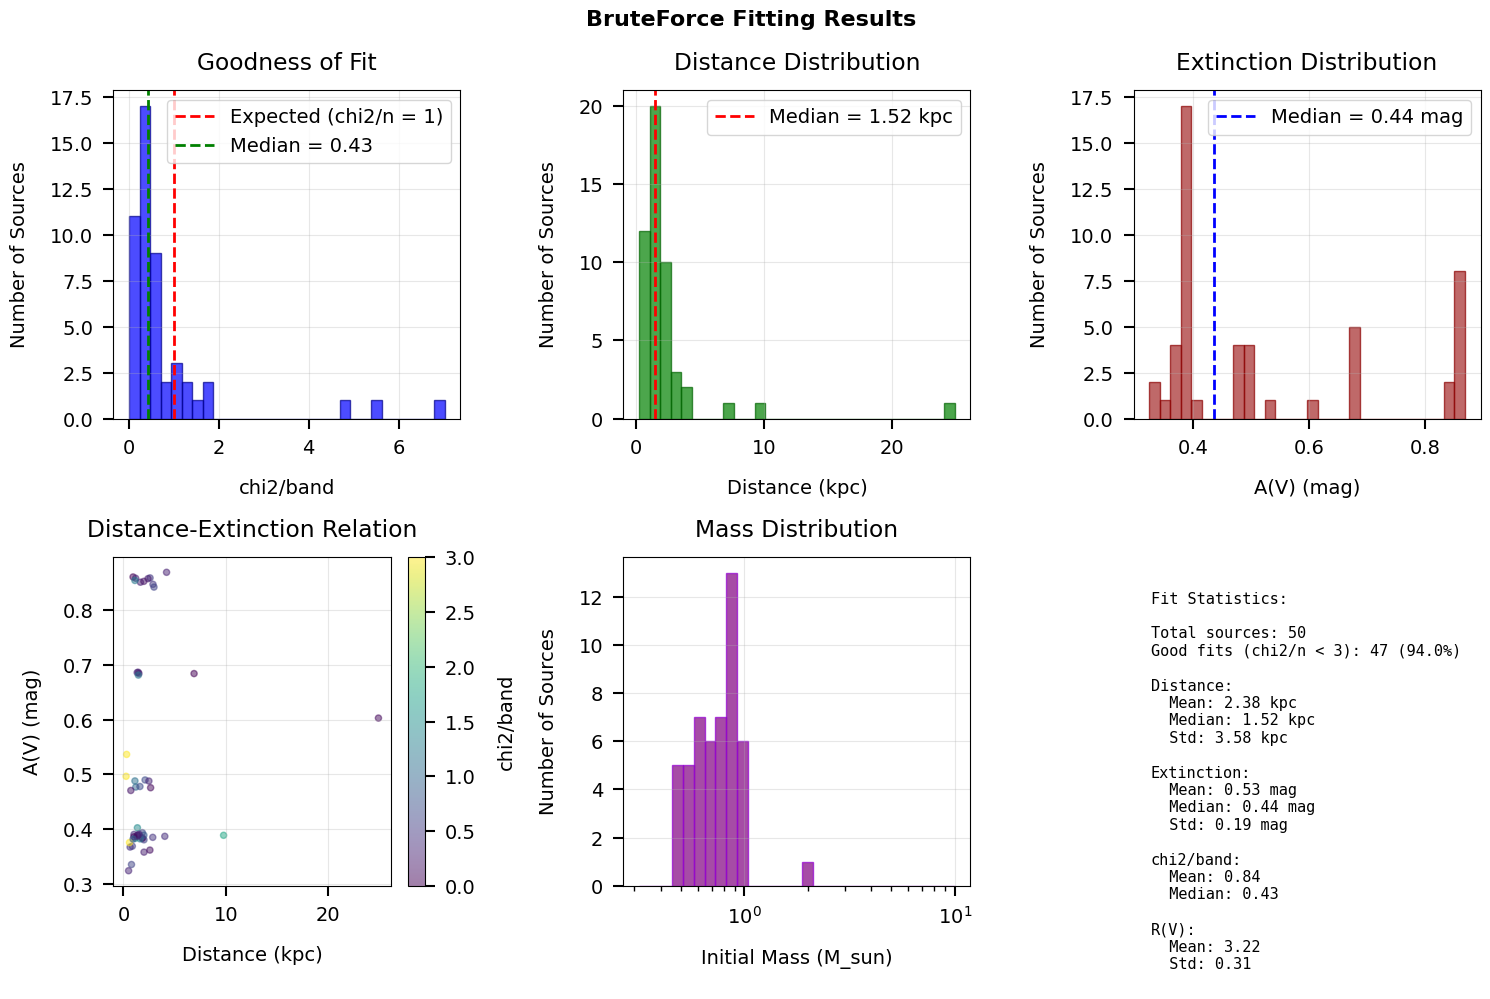


Result analysis complete


In [7]:
# Load and analyze results
import h5py

with h5py.File(output_file, 'r') as f:
    chi2 = f['obj_chi2min'][:]
    nbands = f['obj_Nbands'][:]
    model_idx = f['model_idx'][:]
    ml_scale = f['ml_scale'][:]
    ml_av = f['ml_av'][:]
    ml_rv = f['ml_rv'][:]
    log_post = f['obj_log_post'][:]
    dists = f['samps_dist'][:]
    reds = f['samps_red'][:]
    dreds = f['samps_dred'][:]

print("Loaded fitting results:")
print(f"  chi2 values: {chi2.shape}")
print(f"  Model indices: {model_idx.shape}")
print(f"  ML scale/AV/RV: {ml_scale.shape}")
print(f"  Distance samples: {dists.shape}")

# Compute summary statistics
chi2_per_band = chi2 / nbands
mean_dists = np.mean(dists, axis=1)
mean_av = np.mean(reds, axis=1)

# Create fit quality visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Panel 1: Chi2 distribution
ax = axes[0, 0]
ax.hist(chi2_per_band, bins=30, alpha=0.7, color='blue', edgecolor='darkblue')
ax.axvline(1.0, color='red', ls='--', lw=2, label='Expected (chi2/n = 1)')
ax.axvline(np.median(chi2_per_band), color='green', ls='--', lw=2, label=f'Median = {np.median(chi2_per_band):.2f}')
ax.set_xlabel('chi2/band')
ax.set_ylabel('Number of Sources')
ax.set_title('Goodness of Fit')
ax.legend()
ax.grid(True, alpha=0.3)

# Panel 2: Distance distribution
ax = axes[0, 1]
ax.hist(mean_dists, bins=30, alpha=0.7, color='green', edgecolor='darkgreen')
ax.axvline(np.median(mean_dists), color='red', ls='--', lw=2, label=f'Median = {np.median(mean_dists):.2f} kpc')
ax.set_xlabel('Distance (kpc)')
ax.set_ylabel('Number of Sources')
ax.set_title('Distance Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

# Panel 3: Extinction distribution
ax = axes[0, 2]
ax.hist(mean_av, bins=30, alpha=0.7, color='brown', edgecolor='darkred')
ax.axvline(np.median(mean_av), color='blue', ls='--', lw=2, label=f'Median = {np.median(mean_av):.2f} mag')
ax.set_xlabel('A(V) (mag)')
ax.set_ylabel('Number of Sources')
ax.set_title('Extinction Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

# Panel 4: Distance vs extinction
ax = axes[1, 0]
scatter = ax.scatter(mean_dists, mean_av, alpha=0.5, s=20,
                    c=chi2_per_band, cmap='viridis', vmin=0, vmax=3)
ax.set_xlabel('Distance (kpc)')
ax.set_ylabel('A(V) (mag)')
ax.set_title('Distance-Extinction Relation')
plt.colorbar(scatter, ax=ax, label='chi2/band')
ax.grid(True, alpha=0.3)

# Panel 5: Stellar parameters (using best-fit model per source)
ax = axes[1, 1]

best_draw = np.argmax(log_post, axis=1)
best_model_per_source = model_idx[np.arange(len(chi2)), best_draw]
unique_masses = []
for idx in best_model_per_source:
    if idx < len(labels):
        unique_masses.append(labels[idx]['mini'])

if unique_masses:
    ax.hist(unique_masses, bins=np.logspace(-0.5, 1, 30),
           alpha=0.7, color='purple', edgecolor='darkviolet')
    ax.set_xlabel('Initial Mass (M_sun)')
    ax.set_ylabel('Number of Sources')
    ax.set_title('Mass Distribution')
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3)

# Panel 6: Fit statistics
ax = axes[1, 2]
ax.axis('off')

# Calculate statistics
good_fits = chi2_per_band < 3
stats_text = f"""
Fit Statistics:

Total sources: {len(chi2)}
Good fits (chi2/n < 3): {good_fits.sum()} ({100*good_fits.sum()/len(chi2):.1f}%)

Distance:
  Mean: {np.mean(mean_dists):.2f} kpc
  Median: {np.median(mean_dists):.2f} kpc
  Std: {np.std(mean_dists):.2f} kpc

Extinction:
  Mean: {np.mean(mean_av):.2f} mag
  Median: {np.median(mean_av):.2f} mag
  Std: {np.std(mean_av):.2f} mag

chi2/band:
  Mean: {np.mean(chi2_per_band):.2f}
  Median: {np.median(chi2_per_band):.2f}

R(V):
  Mean: {np.mean(dreds):.2f}
  Std: {np.std(dreds):.2f}
"""

ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
       fontsize=11, va='top', family='monospace')

plt.suptitle('BruteForce Fitting Results', fontsize=16, fontweight='bold')
save_figure(fig, 'fitting_results')
plt.show()

print("\nResult analysis complete")

## Section 4: Visualizing Individual Results

Let's examine individual star fits in detail to understand the posterior distributions and parameter correlations.

In [8]:
# Select a well-fit example star for visualization
# We want chi2/n close to 1 (genuinely good fit) with strong parallax constraint
chi2_quality = np.abs(chi2_per_band - 1.0)  # Distance from ideal chi2/n = 1
parallax_snr = data['parallax'][idx_fit] / data['parallax_err'][idx_fit]

# Rank by fit quality, require decent parallax
candidates = np.argsort(chi2_quality)
for c in candidates:
    if parallax_snr[c] > 5 and nbands[c] >= 6:
        star_idx = c
        break

data_idx = idx_fit[star_idx]

print(f"Selected example star (index {star_idx}):")
print(f"  chi2/n = {chi2[star_idx]/nbands[star_idx]:.3f}")
print(f"  N_bands = {nbands[star_idx]}")
print(f"  Parallax = {data['parallax'][data_idx]:.3f} +/- {data['parallax_err'][data_idx]:.3f} mas (SNR = {parallax_snr[star_idx]:.1f})")
print(f"  Distance = {mean_dists[star_idx]:.2f} +/- {np.std(dists[star_idx]):.3f} kpc")
print(f"  A(V) = {mean_av[star_idx]:.2f} mag")

Selected example star (index 17):
  chi2/n = 1.003
  N_bands = 7
  Parallax = 0.840 +/- 0.032 mas (SNR = 26.3)
  Distance = 1.20 +/- 0.046 kpc
  A(V) = 0.48 mag


### Visualizing a Single Star

brutus provides built-in plotting functions for visualizing individual fitting results. We demonstrate three key plots for the best-fit star.

In [9]:
from brutus.plotting import dist_vs_red, posterior_predictive, cornerplot

print(f"Visualizing star {star_idx}")
print(f"  chi2/n = {chi2[star_idx]/nbands[star_idx]:.3f}")
print(f"  Distance = {mean_dists[star_idx]:.2f} +/- {np.std(dists[star_idx]):.3f} kpc")
print(f"  A(V) = {mean_av[star_idx]:.2f} mag")

Visualizing star 17
  chi2/n = 1.003
  Distance = 1.20 +/- 0.046 kpc
  A(V) = 0.48 mag


  Saved: /mnt/c/Users/joshs/Dropbox/GitHub/brutus/tutorials/plots/tutorial_05/dist_vs_red.png


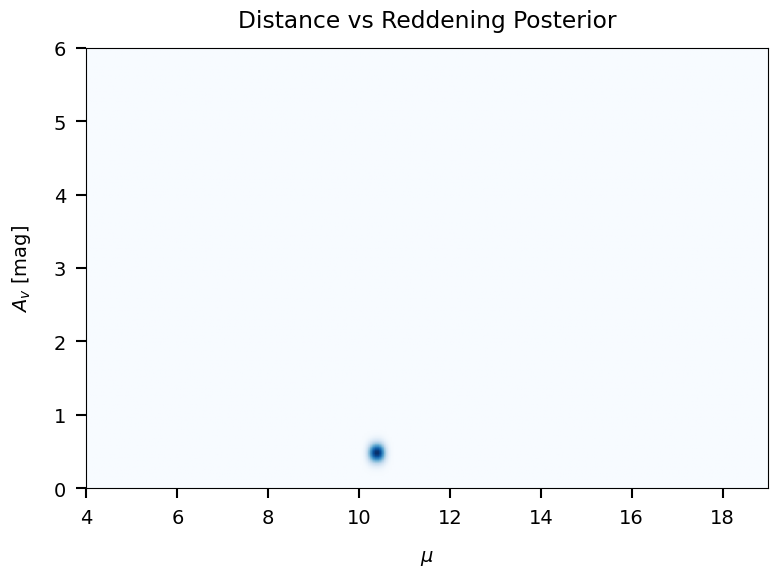

In [10]:
# Distance vs reddening posterior
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
plt.sca(ax)

dist_vs_red(
    (dists[star_idx], reds[star_idx], dreds[star_idx]),
    parallax=data['parallax'][data_idx],
    parallax_err=data['parallax_err'][data_idx],
    coord=(data['coords'][data_idx, 0], data['coords'][data_idx, 1]),
)

plt.title('Distance vs Reddening Posterior')
save_figure(fig, 'dist_vs_red')
plt.show()

  Saved: /mnt/c/Users/joshs/Dropbox/GitHub/brutus/tutorials/plots/tutorial_05/posterior_predictive.png


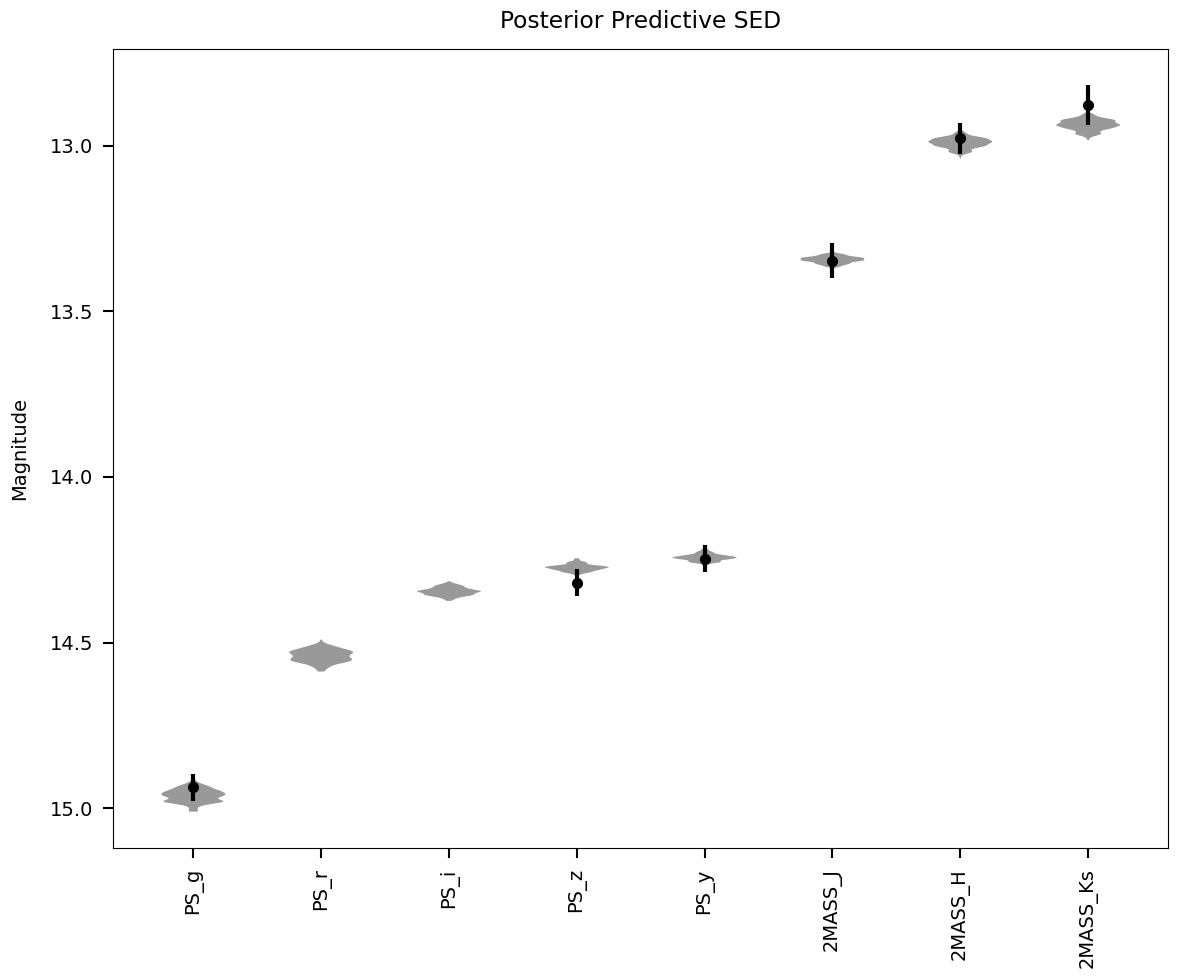

In [11]:
# Posterior predictive SED
fig, ax, parts = posterior_predictive(
    models,
    idxs=model_idx[star_idx],
    reds=reds[star_idx],
    dreds=dreds[star_idx],
    dists=dists[star_idx],
    data=data['phot'][data_idx],
    data_err=data['err'][data_idx],
    data_mask=data['mask'][data_idx],
    offset=offsets_mist,
    labels=filt,
)

plt.title('Posterior Predictive SED')
save_figure(fig, 'posterior_predictive')
plt.show()

  Saved: /mnt/c/Users/joshs/Dropbox/GitHub/brutus/tutorials/plots/tutorial_05/cornerplot.png


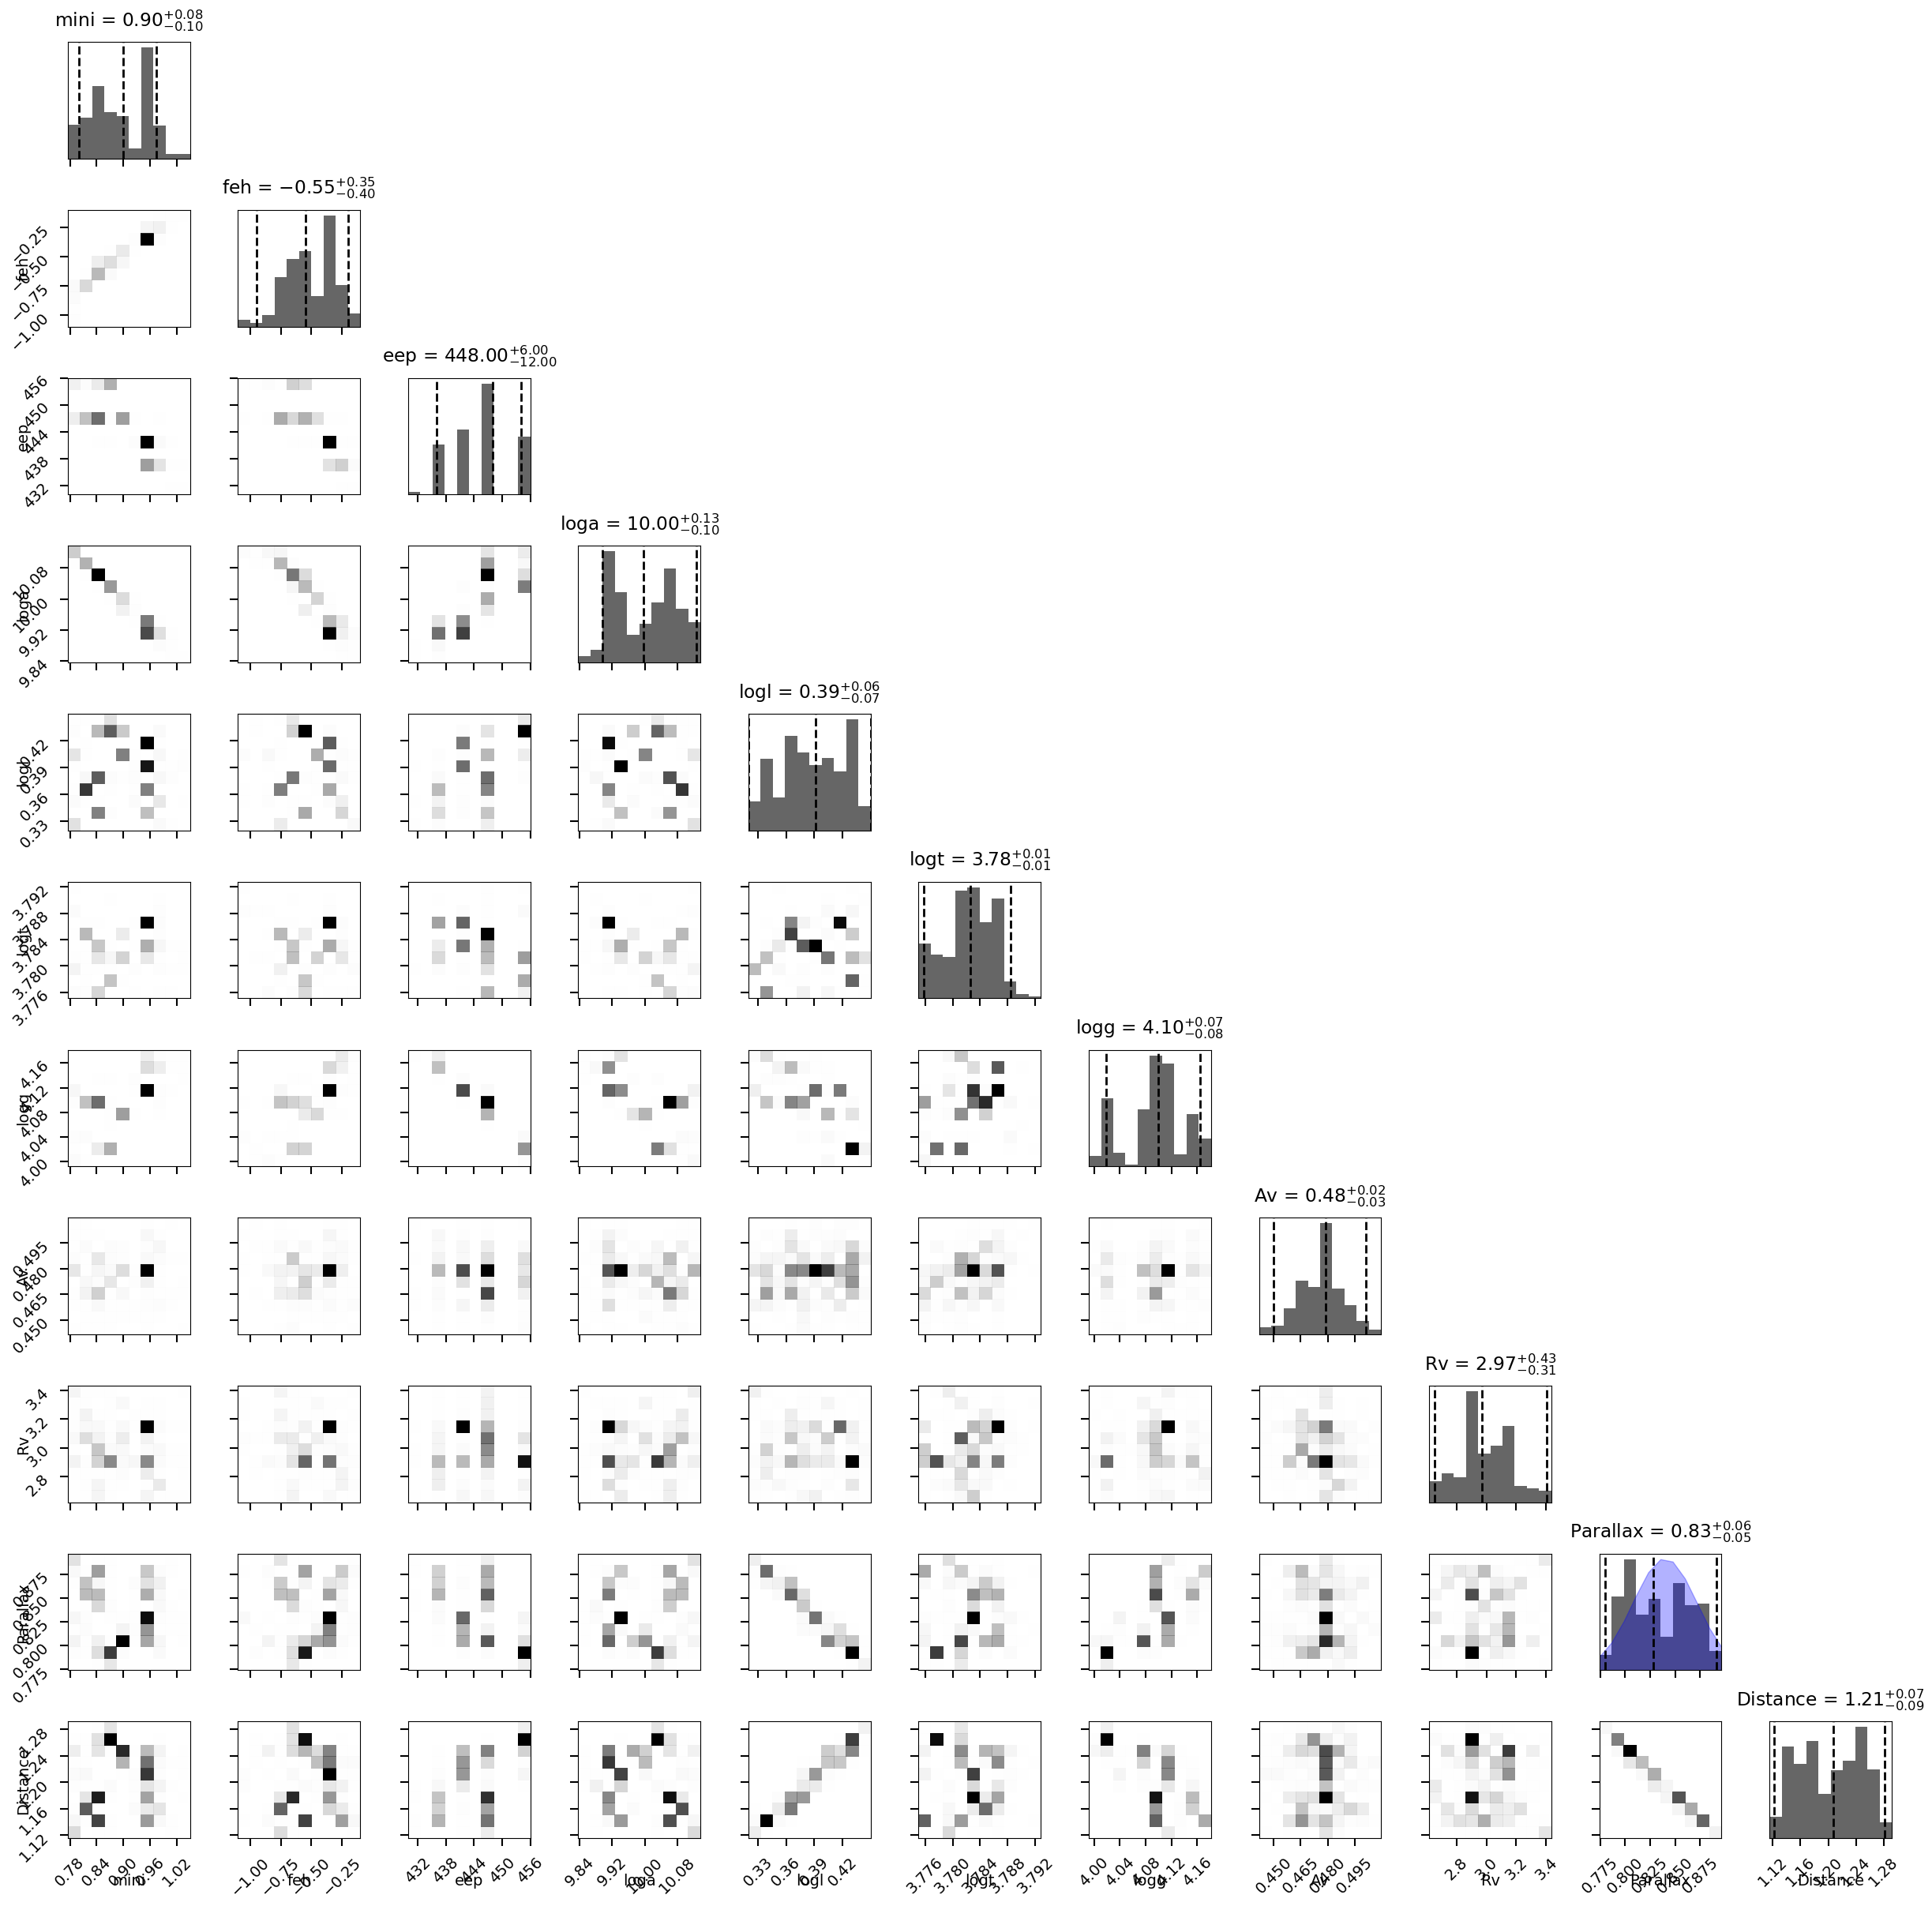

In [12]:
# Corner plot of stellar parameters
fig, axes = cornerplot(
    idxs=model_idx[star_idx],
    data=(dists[star_idx], reds[star_idx], dreds[star_idx]),
    params=labels,
    coord=(data['coords'][data_idx, 0], data['coords'][data_idx, 1]),
    parallax=data['parallax'][data_idx],
    parallax_err=data['parallax_err'][data_idx],
    show_titles=True,
)

save_figure(fig, 'cornerplot')
plt.show()

## Section: Impact of the 3D Dust Map Prior

The Bayestar 3D dust map provides distance-dependent extinction constraints
that can significantly affect the inferred stellar parameters. When a dust map
is available, `BruteForce` evaluates the extinction prior at each candidate
distance, preferring (distance, A_V) combinations consistent with the
cumulative dust profile along the line of sight.

To quantify this effect, we re-fit the same sources **without** the dust map
prior and compare the resulting distance and extinction posteriors. Sources in
highly extincted regions (like Orion) should show the largest differences.

Running comparison fit WITHOUT dust map prior on 50 sources...


Fitting object 1/50  

Fitting object 2/50 [chi2/n: 0.1/6] (mean time: 0.419 s/obj, est. remaining: 20.524 s)    

Fitting object 3/50 [chi2/n: 1.8/7] (mean time: 0.398 s/obj, est. remaining: 19.110 s)    

Fitting object 4/50 [chi2/n: 4.4/9] (mean time: 0.474 s/obj, est. remaining: 22.283 s)    

...

Fitting object 48/50 [chi2/n: 4.0/9] (mean time: 0.473 s/obj, est. remaining: 1.418 s)    

Fitting object 49/50 [chi2/n: 44.2/9] (mean time: 0.473 s/obj, est. remaining: 0.947 s)    

Fitting object 50/50 [chi2/n: 0.5/7] (mean time: 0.478 s/obj, est. remaining: 0.478 s)    

Fitting object 50/50 [chi2/n: 6.6/8] (mean time: 0.477 s/obj, total: 23.838 s)    



Comparison fit complete! Saved to /mnt/c/Users/joshs/Dropbox/GitHub/brutus/tutorials/plots/tutorial_05/orion_fits_mist_nodust.h5
  Saved: /mnt/c/Users/joshs/Dropbox/GitHub/brutus/tutorials/plots/tutorial_05/dust_prior_comparison.png


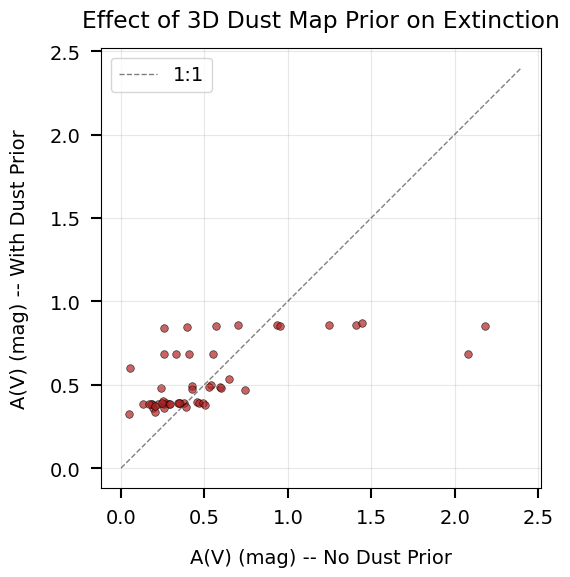


Dust prior comparison complete


In [13]:
# Re-fit the same sources WITHOUT the dust map prior
if dustfile is not None:
    output_file_nodust = plots_dir / 'orion_fits_mist_nodust.h5'

    print(f"Running comparison fit WITHOUT dust map prior on {len(idx_fit)} sources...")

    bf.fit(
        data=data['phot'][idx_fit],
        data_err=data['err'][idx_fit],
        data_mask=data['mask'][idx_fit],
        data_labels=idx_fit,
        save_file=str(output_file_nodust),
        data_coords=data['coords'][idx_fit],
        parallax=data['parallax'][idx_fit],
        parallax_err=data['parallax_err'][idx_fit],
        phot_offsets=offsets_mist,
        dustfile=None,  # <-- No dust map
        Ndraws=500,
        Nmc_prior=20,
        logl_dim_prior=True,
        save_dar_draws=True,
        running_io=False,
        verbose=True
    )

    print(f"\nComparison fit complete! Saved to {output_file_nodust}")

    # --- Load both result sets ---
    with h5py.File(output_file, 'r') as f:
        reds_dust = f['samps_red'][:]

    with h5py.File(output_file_nodust, 'r') as f:
        reds_nodust = f['samps_red'][:]

    mean_av_dust = np.mean(reds_dust, axis=1)
    mean_av_nodust = np.mean(reds_nodust, axis=1)

    # --- Single-panel A(V) comparison ---
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(mean_av_nodust, mean_av_dust, s=30, alpha=0.7,
               c='firebrick', edgecolor='k', lw=0.5)
    lim = [0, max(mean_av_dust.max(), mean_av_nodust.max()) * 1.1]
    ax.plot(lim, lim, 'k--', lw=1, alpha=0.5, label='1:1')
    ax.set_xlabel('A(V) (mag) -- No Dust Prior')
    ax.set_ylabel('A(V) (mag) -- With Dust Prior')
    ax.set_title('Effect of 3D Dust Map Prior on Extinction')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

    save_figure(fig, 'dust_prior_comparison')
    plt.show()

    print("\nDust prior comparison complete")
else:
    print("Dust map not available -- skipping comparison.")
    print("The dust prior comparison requires bayestar2019_v1.h5")

## Section: Advanced BruteForce Options

`BruteForce.fit()` accepts many parameters beyond the basics shown earlier.
Understanding these options lets you tune performance, control output size,
and adjust the statistical model to match your science case.

The parameters fall into several categories:

- **Likelihood control**: `logl_dim_prior` switches between a standard Gaussian
  log-likelihood and a chi-square dimensionality-corrected version that penalizes
  over-fitting (or under-fitting) relative to the number of observed bands.

- **Prior adjustments**: `apply_agewt` adds an age-based weight from the MIST
  evolutionary tracks (accounting for time spent in each evolutionary phase).
  `apply_grad` applies a gradient-based correction for non-uniform grid spacing.
  `av_gauss` lets you impose a Gaussian prior on A(V) instead of using the
  distance-reddening relation from a 3D dust map.

- **Output thresholds**: `wt_thresh` and `cdf_thresh` control which models are
  kept in the posterior sampling. Raising these thresholds reduces output file
  size at the cost of potentially trimming the tails of the posterior.

The cell below prints a reference table of these advanced parameters. It does
**not** run a fit (which would be too slow for an interactive tutorial).

In [14]:
# Advanced BruteForce.fit() parameter reference
# This cell documents parameters -- it does NOT run a fit.

advanced_params = [
    # (parameter, default, description)
    ("logl_dim_prior", "True",
     "Use chi-square dimensionality prior on the likelihood.\n"
     "True  -> penalizes models based on chi2 relative to DOF (recommended).\n"
     "False -> standard Gaussian log-likelihood (no DOF correction)."),

    ("apply_agewt", "True",
     "Apply age-based weighting from MIST evolutionary tracks.\n"
     "Accounts for the different amounts of time a star spends\n"
     "in each evolutionary phase (e.g., main sequence vs. giant branch)."),

    ("apply_grad", "True",
     "Apply gradient-based correction for non-uniform grid spacing.\n"
     "Corrects for the fact that model grid points are not evenly\n"
     "distributed in parameter space (mass, age, metallicity)."),

    ("av_gauss", "None",
     "Gaussian prior on A(V) as a (mean, std) tuple.\n"
     "Example: av_gauss=(0.5, 0.2) centers extinction at A(V)=0.5 mag.\n"
     "If None, uses the distance-reddening relation from the dust map."),

    ("wt_thresh", "1e-3",
     "Weight threshold for model selection: keeps models with\n"
     "weight > wt_thresh * max(weight). Lower values keep more\n"
     "models (broader posterior tails) but increase output size."),

    ("cdf_thresh", "2e-3",
     "CDF threshold for model selection. Models contributing less\n"
     "than this fraction of cumulative probability are discarded.\n"
     "Used as fallback if wt_thresh is None."),

    ("Ndraws", "250",
     "Number of posterior samples saved per object.\n"
     "More draws give smoother posteriors but larger output files.\n"
     "Typical range: 100 (quick) to 500 (publication quality)."),

    ("Nmc_prior", "50",
     "Number of Monte Carlo samples for prior integration.\n"
     "Higher values improve accuracy of the distance/extinction\n"
     "marginalization at the cost of computation time."),

    ("rv_gauss", "(3.32, 0.18)",
     "Gaussian prior on R(V) as a (mean, std) tuple.\n"
     "Default based on Schlafly et al. (2016).\n"
     "Set to None to use a flat prior within rvlim bounds."),

    ("running_io", "True",
     "If True, writes each object to disk immediately after fitting.\n"
     "Safer for long runs (recoverable on crash) but slower on\n"
     "network filesystems. Set False to batch-write at the end."),
]

# Print formatted table
print("Advanced BruteForce.fit() Parameters")
print("=" * 72)

for param, default, desc in advanced_params:
    print(f"\n  {param}  (default: {default})")
    print("  " + "-" * 68)
    for line in desc.split("\n"):
        print(f"    {line}")

print("\n" + "=" * 72)
print("\nExample usage with advanced options:")
print("""
    bf.fit(
        data=flux, data_err=flux_err, data_mask=mask,
        data_labels=obj_ids, save_file='results.h5',
        # --- advanced options ---
        logl_dim_prior=True,      # recommended for robust fitting
        apply_agewt=True,         # weight by evolutionary timescales
        apply_grad=True,          # correct for grid spacing
        av_gauss=(0.3, 0.1),     # informative A(V) prior
        rv_gauss=(3.32, 0.18),   # Schlafly+2016 R(V) prior
        wt_thresh=1e-3,           # keep top 0.1% of models
        cdf_thresh=2e-3,          # CDF cutoff
        Ndraws=250,               # posterior samples per source
        Nmc_prior=50,             # MC prior samples
        running_io=True,          # write results incrementally
    )
""")

Advanced BruteForce.fit() Parameters

  logl_dim_prior  (default: True)
  --------------------------------------------------------------------
    Use chi-square dimensionality prior on the likelihood.
    True  -> penalizes models based on chi2 relative to DOF (recommended).
    False -> standard Gaussian log-likelihood (no DOF correction).

  apply_agewt  (default: True)
  --------------------------------------------------------------------
    Apply age-based weighting from MIST evolutionary tracks.
    Accounts for the different amounts of time a star spends
    in each evolutionary phase (e.g., main sequence vs. giant branch).

  apply_grad  (default: True)
  --------------------------------------------------------------------
    Apply gradient-based correction for non-uniform grid spacing.
    Corrects for the fact that model grid points are not evenly
    distributed in parameter space (mass, age, metallicity).

  av_gauss  (default: None)
  ------------------------------------

## Summary and Key Takeaways

This tutorial has demonstrated how to fit individual stars using BruteForce:

### Key Steps

1. **Data Preparation**
   - Convert magnitudes to flux (maggies)
   - Ensure proper error arrays and masks
   - Include parallax and coordinates when available

2. **Model Setup**
   - Load pre-computed model grids (MIST)
   - Apply photometric offsets for calibration
   - Initialize BruteForce with models

3. **Running Fits**
   - Configure priors (Galactic, dust, parallax)
   - Set sampling parameters (Ndraws, Nmc_prior)
   - Save results to HDF5 for analysis

4. **Result Analysis**
   - Examine chi-squared distributions for fit quality
   - Analyze parameter distributions and correlations
   - Visualize individual SEDs and posteriors

### Best Practices

- **Data Quality**: Require SNR > 5 and >= 3 bands per source
- **Photometric Offsets**: Always apply appropriate calibrations
- **Priors**: Use 3D dust maps and parallax when available
- **Validation**: Check chi-squared/n values (should be ~1 for good fits)
- **Uncertainties**: Use posterior samples for proper error estimation

### Next Steps

- **Tutorial 6**: Cluster Analysis and Population Fitting
- **Tutorial 7**: 3D Dust Mapping
- **Tutorial 8**: Photometric Calibration

In [15]:
print("Tutorial 5 Complete!")
print("="*60)
print("\nGenerated plots:")
for plot_file in sorted(plots_dir.glob('*.png')):
    print(f"  - {plot_file.name}")
    
print("\nOutput files:")
for h5_file in sorted(plots_dir.glob('*.h5')):
    print(f"  - {h5_file.name}")

Tutorial 5 Complete!

Generated plots:
  - bruteforce_setup.png
  - cornerplot.png
  - data_preparation.png
  - dist_vs_red.png
  - dust_prior_comparison.png
  - fitting_results.png
  - individual_results.png
  - likelihood_comparison.png
  - posterior_predictive.png

Output files:
  - orion_fits_mist.h5
  - orion_fits_mist_nodust.h5
